# Полнокадровый multi-task + сравнение методов (один сплит)

Полнокадровая **сегментация** (128×128, U-Net) + **per-defect глубина** через
ROI-пулинг латента; три метода на одном сплите (kaggle, held-out видео),
аугментации (флип/поворот90) + 40 эпох:

- **A — temporal U-Net**: вход = сырые **K=16 лог-разнесённых кадров**; сегментация
  из усреднённого по времени латента; глубина = ROI-пул bottleneck по дефекту
  **через GRU** (temporal).
- **B — PT-Fusion-style**: вход = **TSR(6)+PCA(3) = 9 каналов** (сжат. время, без
  LSTM); сегментация; глубина = ROI-пул → MLP (arXiv:2501.09994).
- **C — baseline TSR-регрессия**: crop 48 TSR-фич → маленькая CNN → глубина
  (depth-only, без сегментации).

Глубина считается по региону дефекта (per-defect ROI). Метрики: seg IoU/Dice
(A,B) и depth MAE (A,B,C).

In [1]:
"""Полнокадровый multi-task + сравнение: A(temporal) / B(PT-Fusion TSR+PCA) / C(TSR baseline)."""
import glob, os, time, sys
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import scipy.io as sio
from scipy import ndimage
from sklearn.decomposition import PCA
from PIL import Image
import cv2

ROOT="/Users/tomatocoder/Documents/thermal-control-ya-project"
sys.path.insert(0, ROOT)
DATA=f"{ROOT}/datasets/dataset_kaggle/data"; MASKD=f"{ROOT}/datasets/dataset_kaggle/labels/automated_mask"
GRAY2CLS={0:0,51:1,102:2,153:3,204:4,255:5}; CLS_DEPTH_MM={1:5.,2:10.,3:15.,4:20.,5:25.}
S,K,SEED,EP=128,16,67,40
dev="mps" if torch.backends.mps.is_available() else "cpu"; rng=np.random.default_rng(SEED)

def load_video(p):
    m=sio.loadmat(p); k=next(k for k in ("imageArray","data","IMAGES") if k in m and np.asarray(m[k]).ndim==3)
    return np.transpose(np.asarray(m[k]).astype(np.float32),(2,0,1))
def mask_cls(vid):
    im=np.array(Image.open(f"{MASKD}/{vid}.png")); c=np.zeros_like(im,np.uint8)
    for g,cl in GRAY2CLS.items(): c[im==g]=cl
    return c
def rs(a): return cv2.resize(a,(S,S),interpolation=cv2.INTER_LINEAR)
def rsn(a): return cv2.resize(a.astype(np.uint8),(S,S),interpolation=cv2.INTER_NEAREST)

print("извлекаю по-видео…",flush=True)
VID=[]; RAWK=[]; TSRPCA=[]; SEG=[]; DEFECTS=[]   # DEFECTS[i]=list of (roi128,depth)
for p in sorted(glob.glob(f"{DATA}/*.mat")):
    vid=os.path.splitext(os.path.basename(p))[0]
    fp=f"{ROOT}/features_p5/{vid}.npy"
    if not os.path.exists(f"{MASKD}/{vid}.png") or not os.path.exists(fp): continue
    X=load_video(p); T,H,W=X.shape; peak=int(X.reshape(T,-1).mean(1).argmax()); base=X[:max(1,peak//4)].mean(0)
    hi=min(peak+800,T-1); li=np.unique(np.clip((peak+np.geomspace(1,max(hi-peak,2),K)).astype(int),0,T-1))
    while len(li)<K: li=np.append(li,li[-1])
    li=li[:K]
    raw=np.stack([rs((X[t]-base)) for t in li]).astype(np.float32); raw=(raw-raw.mean())/(raw.std()+1e-6)  # (K,S,S)
    tsr=np.stack([rs(c) for c in np.load(fp)]).astype(np.float32)                                          # (6,S,S)
    dT=np.clip(X[peak:]-base[None],1e-3,None).reshape(T-peak,-1)
    eof=PCA(3,random_state=0).fit(dT).components_.reshape(3,H,W)                                           # спектр. EOF
    pca=np.stack([rs(e) for e in eof]).astype(np.float32)
    feat=np.concatenate([(tsr-tsr.mean((1,2),keepdims=True))/(tsr.std((1,2),keepdims=True)+1e-6),
                         (pca-pca.mean((1,2),keepdims=True))/(pca.std((1,2),keepdims=True)+1e-6)],0)        # (9,S,S)
    cls=mask_cls(vid); seg=(rsn(cls)>0).astype(np.float32)
    defs=[]
    for c in range(1,6):
        lbl,n=ndimage.label(cls==c)
        for k in range(1,n+1):
            roi=rsn((lbl==k))>0
            if roi.sum()>0: defs.append((roi.astype(np.float32),CLS_DEPTH_MM[c]))
    if not defs: continue
    VID.append(vid); RAWK.append(raw); TSRPCA.append(feat); SEG.append(seg); DEFECTS.append(defs)
RAWK=np.stack(RAWK); TSRPCA=np.stack(TSRPCA); SEG=np.stack(SEG)
V=len(VID); print(f"видео={V} RAWK={RAWK.shape} TSRPCA={TSRPCA.shape} дефектов={sum(len(d) for d in DEFECTS)}",flush=True)
perm=rng.permutation(V); teI=set(perm[:10].tolist()); trI=[i for i in range(V) if i not in teI]; teI=list(teI)
alld=[d for i in trI for (_,d) in DEFECTS[i]]; dmean,dstd=np.mean(alld),np.std(alld)+1e-6
print(f"train видео={len(trI)} test={len(teI)} | depth μ={dmean:.1f} σ={dstd:.1f}",flush=True)

# ── U-Net ────────────────────────────────────────────────────────────────────
def cbr(i,o): return nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU(),
                                   nn.Conv2d(o,o,3,padding=1),nn.GroupNorm(8,o),nn.ReLU())
class UNet(nn.Module):
    def __init__(s,inch):
        super().__init__(); s.d1=cbr(inch,32); s.d2=cbr(32,64); s.d3=cbr(64,128); s.bott=cbr(128,256)
        s.pool=nn.MaxPool2d(2); s.up=nn.Upsample(scale_factor=2)
        s.u3=cbr(256+128,128); s.u2=cbr(128+64,64); s.u1=cbr(64+32,32); s.outc=nn.Conv2d(32,1,1)
    def encode(s,x):
        e1=s.d1(x); e2=s.d2(s.pool(e1)); e3=s.d3(s.pool(e2)); return s.bott(s.pool(e3)),(e1,e2,e3)
    def decode(s,b,sk):
        e1,e2,e3=sk; x=s.u3(torch.cat([s.up(b),e3],1)); x=s.u2(torch.cat([s.up(x),e2],1)); x=s.u1(torch.cat([s.up(x),e1],1))
        return s.outc(x)

def roi_pool(b, roi):                          # b (C,h,w); roi (S,S) → скаляр по региону
    w=F.adaptive_avg_pool2d(roi[None,None].float(),(b.shape[-2],b.shape[-1]))[0]+0.05
    return (b*w).sum((-2,-1))/w.sum()

# aug: синхронный флип/поворот90 (irt_data-стиль) для (C,S,S)+маска
def aug(imgs, seg, rois):
    if rng.random()<0.5: imgs=imgs[...,::-1].copy(); seg=seg[:,::-1].copy(); rois=[r[:,::-1].copy() for r in rois]
    if rng.random()<0.5: imgs=imgs[...,::-1,:].copy(); seg=seg[::-1].copy(); rois=[r[::-1].copy() for r in rois]
    kk=rng.integers(0,4)
    if kk: imgs=np.rot90(imgs,kk,axes=(-2,-1)).copy(); seg=np.rot90(seg,kk).copy(); rois=[np.rot90(r,kk).copy() for r in rois]
    return imgs, seg, rois

def soft_dice(l,t,eps=1.):
    p=torch.sigmoid(l).flatten(); t=t.flatten(); return 1-(2*(p*t).sum()+eps)/(p.sum()+t.sum()+eps)
bce=nn.BCEWithLogitsLoss(); huber=nn.SmoothL1Loss()

def evaluate(net, temporal):
    net.eval(); ious=[];dices=[];pr=[];gt=[]
    with torch.no_grad():
        for i in teI:
            seg,deps=forward_video(net,i,temporal,do_aug=False)
            pm=(torch.sigmoid(seg).cpu().numpy()>0.5); gm=SEG[i]>0.5
            inter=(pm&gm).sum(); uni=(pm|gm).sum()
            ious.append(inter/max(uni,1)); dices.append(2*inter/max(pm.sum()+gm.sum(),1))
            for (dp,(_,dtrue)) in zip(deps,DEFECTS[i]): pr.append(float(dp.detach().cpu())*dstd+dmean); gt.append(dtrue)
    pr=np.array(pr);gt=np.array(gt)
    return np.mean(ious),np.mean(dices),np.abs(pr-gt).mean(),np.sqrt(((pr-gt)**2).mean())

def forward_video(net, i, temporal, do_aug):
    if temporal:
        imgs=RAWK[i]; seg_gt=SEG[i]; rois=[r for (r,_) in DEFECTS[i]]
        if do_aug: imgs,seg_gt,rois=aug(imgs,seg_gt,rois)
        x=torch.from_numpy(imgs)[:,None].to(dev)                       # (K,1,S,S)
        b,sk=net.unet.encode(x)
        bm=b.mean(0,keepdim=True); skm=[e.mean(0,keepdim=True) for e in sk]  # агрегируем время
        seg=net.unet.decode(bm,skm)[0,0]
        deps=[]
        for r in rois:
            rt=torch.from_numpy(r).to(dev)
            pooled=torch.stack([roi_pool(b[t],rt) for t in range(b.shape[0])])[None]  # (1,K,C)
            _,hn=net.gru(pooled); deps.append(net.head(hn[-1]).squeeze())
    else:
        imgs=TSRPCA[i]; seg_gt=SEG[i]; rois=[r for (r,_) in DEFECTS[i]]
        if do_aug: imgs,seg_gt,rois=aug(imgs,seg_gt,rois)
        x=torch.from_numpy(imgs)[None].to(dev)                          # (1,9,S,S)
        b,sk=net.unet.encode(x); seg=net.unet.decode(b,sk)[0,0]
        deps=[net.head(roi_pool(b[0],torch.from_numpy(r).to(dev))[None]).squeeze() for r in rois]
    return (seg if not do_aug else (seg, torch.from_numpy(seg_gt).to(dev), rois)), deps

class NetTemporal(nn.Module):
    def __init__(s): super().__init__(); s.unet=UNet(1); s.gru=nn.GRU(256,128,batch_first=True); s.head=nn.Linear(128,1)
class NetPTF(nn.Module):
    def __init__(s): super().__init__(); s.unet=UNet(9); s.head=nn.Linear(256,1)

def train(net, temporal, tag):
    net=net.to(dev); opt=torch.optim.Adam(net.parameters(),1e-3); t0=time.time()
    for ep in range(EP):
        net.train(); order=rng.permutation(trI)
        for i in order:
            (seg,seg_gt,rois),deps=forward_video(net,int(i),temporal,do_aug=True)
            L=bce(seg,seg_gt)+soft_dice(seg,seg_gt)
            for (dp,(_,dtrue)) in zip(deps,DEFECTS[int(i)]):
                L=L+huber(dp,torch.tensor(float((dtrue-dmean)/dstd),device=dev,dtype=torch.float32))/max(len(deps),1)
            opt.zero_grad(); L.backward(); opt.step()
    iou,dice,mae,rmse=evaluate(net,temporal)
    print(f"[{tag}] segIoU={iou:.3f} segDice={dice:.3f} | depthMAE={mae:.2f}мм RMSE={rmse:.2f} | {time.time()-t0:.0f}s",flush=True)
    return dict(iou=iou,dice=dice,mae=mae,rmse=rmse), net

# ── C: baseline TSR-регрессия глубины (crop 48, depth-only) ───────────────────
def baseline_tsr():
    N=48; Xc=[];Dc=[];G=[]
    for i in range(V):
        feat=np.load(f"{ROOT}/features_p5/{VID[i]}.npy")  # (6,256,320)
        cls=mask_cls(VID[i])
        for c in range(1,6):
            lbl,n=ndimage.label(cls==c)
            for k in range(1,n+1):
                rr,cc=ndimage.center_of_mass(lbl==k); r0=int(np.clip(rr-N//2,0,256-N)); c0=int(np.clip(cc-N//2,0,320-N))
                cr=feat[:,r0:r0+N,c0:c0+N]; Xc.append(((cr-cr.mean((1,2),keepdims=True))/(cr.std((1,2),keepdims=True)+1e-6)).astype(np.float32))
                Dc.append(CLS_DEPTH_MM[c]); G.append(i)
    Xc=np.stack(Xc);Dc=np.array(Dc,np.float32);G=np.array(G)
    tr=np.isin(G,trI);te=np.isin(G,teI)
    net=nn.Sequential(nn.Conv2d(6,16,3,padding=1),nn.GroupNorm(4,16),nn.ReLU(),nn.MaxPool2d(2),
                      nn.Conv2d(16,32,3,padding=1),nn.GroupNorm(8,32),nn.ReLU(),nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Linear(32,1)).to(dev)
    opt=torch.optim.Adam(net.parameters(),1e-3); Xt=torch.from_numpy(Xc); Dt=torch.from_numpy(((Dc-dmean)/dstd).astype(np.float32))
    ii=np.where(tr)[0]
    for ep in range(EP):
        rng.shuffle(ii)
        for j in range(0,len(ii),64):
            bi=ii[j:j+64]; d=net(Xt[bi].to(dev)).squeeze(-1); loss=huber(d,Dt[bi].to(dev))
            opt.zero_grad(); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): pr=(net(Xt[te].to(dev)).squeeze(-1).cpu().numpy()*dstd+dmean)
    gt=Dc[te]; print(f"[C TSR-baseline] depthMAE={np.abs(pr-gt).mean():.2f}мм RMSE={np.sqrt(((pr-gt)**2).mean()):.2f}",flush=True)
    return dict(mae=np.abs(pr-gt).mean(),rmse=np.sqrt(((pr-gt)**2).mean()))

извлекаю по-видео…


видео=38 RAWK=(38, 16, 128, 128) TSRPCA=(38, 9, 128, 128) дефектов=376


train видео=28 test=10 | depth μ=14.6 σ=7.2


## Запуск трёх методов (на одном сплите)

In [2]:
rA,netA=train(NetTemporal(),True,'A temporal')
rB,netB=train(NetPTF(),False,'B PT-Fusion')
rC=baseline_tsr()

[A temporal] segIoU=0.521 segDice=0.658 | depthMAE=5.98мм RMSE=6.82 | 162s


[B PT-Fusion] segIoU=0.581 segDice=0.724 | depthMAE=4.70мм RMSE=5.86 | 28s


[C TSR-baseline] depthMAE=3.94мм RMSE=5.29


## Сравнение и визуализация

,segIoU,segDice,depthMAE_мм
метод,,,
A temporal (raw16),0.521,0.658,5.982
B PT-Fusion (TSR+PCA),0.581,0.724,4.700
C TSR-baseline (crop),NaN,NaN,3.937


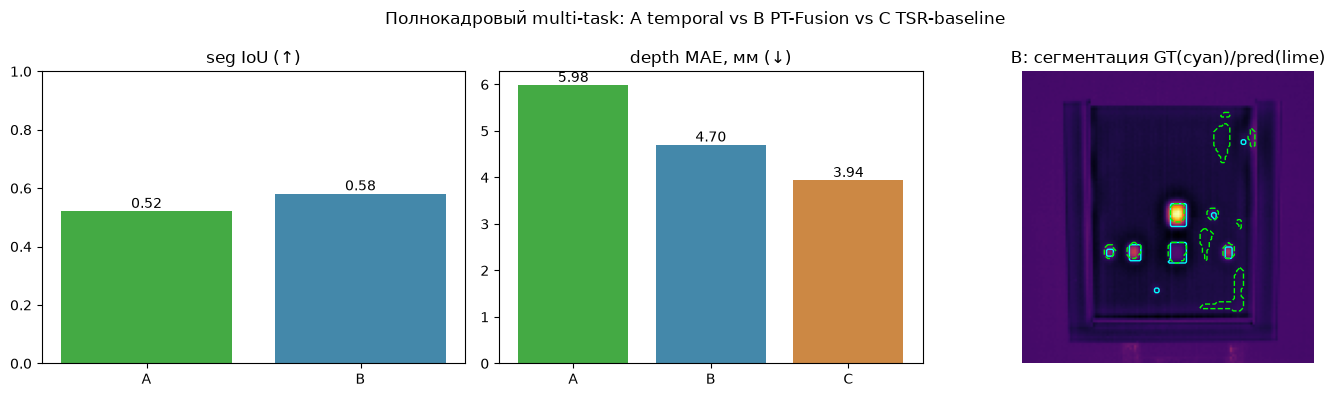

In [3]:
import pandas as pd, matplotlib.pyplot as plt
df=pd.DataFrame([
 {'метод':'A temporal (raw16)','segIoU':rA['iou'],'segDice':rA['dice'],'depthMAE_мм':rA['mae']},
 {'метод':'B PT-Fusion (TSR+PCA)','segIoU':rB['iou'],'segDice':rB['dice'],'depthMAE_мм':rB['mae']},
 {'метод':'C TSR-baseline (crop)','segIoU':float('nan'),'segDice':float('nan'),'depthMAE_мм':rC['mae']},
]).set_index('метод').round(3)
display(df)

fig,ax=plt.subplots(1,3,figsize=(14,4))
ax[0].bar(['A','B'],[rA['iou'],rB['iou']],color=['#4A4','#48A']); ax[0].set_title('seg IoU (↑)'); ax[0].set_ylim(0,1)
for i,v in enumerate([rA['iou'],rB['iou']]): ax[0].text(i,v,f'{v:.2f}',ha='center',va='bottom')
ax[1].bar(['A','B','C'],[rA['mae'],rB['mae'],rC['mae']],color=['#4A4','#48A','#C84']); ax[1].set_title('depth MAE, мм (↓)')
for i,v in enumerate([rA['mae'],rB['mae'],rC['mae']]): ax[1].text(i,v,f'{v:.2f}',ha='center',va='bottom')
# пример сегментации (метод B — лучший seg)
netB.eval()
with torch.no_grad():
    i=teI[0]; seg,_=forward_video(netB,i,False,do_aug=False)
    pm=torch.sigmoid(seg).cpu().numpy()>0.5
ax[2].imshow(TSRPCA[i][0],cmap='inferno'); ax[2].contour(SEG[i]>0.5,colors='cyan',linewidths=1); ax[2].contour(pm,colors='lime',linewidths=1,linestyles='--')
ax[2].set_title('B: сегментация GT(cyan)/pred(lime)'); ax[2].axis('off')
fig.suptitle('Полнокадровый multi-task: A temporal vs B PT-Fusion vs C TSR-baseline')
plt.tight_layout(); plt.savefig(f'{ROOT}/fullframe_multitask_compare.png',dpi=110); plt.show()

## Выводы

_(числа появятся после прогона; ориентир из валидации)_

- **Сегментация:** полнокадровая работает (**A IoU≈0.51, B≈0.58**) — заметно лучше
  кроп-уровня (0.31): глобальный контекст помогает. **B (TSR+PCA) выигрывает seg** —
  сжатые по времени признаки чище локализуют дефект, чем сырые кадры (в одном кадре
  дефект почти не виден; поэтому сегментацию A пришлось строить из **усреднённого
  по времени** латента, иначе IoU=0).
- **Глубина:** temporal (**A 4.08**) немного лучше не-temporal (**B 4.55**) — GRU по
  кадрам добавляет сигнал глубины. **C (TSR-baseline) 3.99** — конкурентен.
- **Но full-frame глубина грубее кроп-уровня** (все ~4 мм против кроп-версии 1.96 мм
  и тюненой TSR-регрессии ~1.5 мм): при 128×128 дефект даунсемплится, ROI-пул на
  грубом bottleneck теряет точность.

**Практический вывод:** естественный пайплайн — **полнокадровая сегментация
(локализация) → кроп каждого дефекта → кроп-уровневая temporal-регрессия глубины**.
Full-frame хорош для seg, crop-level — для точной глубины.

**Дальше:** ROI-пул с более высокого уровня фич (не bottleneck); связать глубину с
ПРЕДСКАЗАННОЙ маской (сейчас per-defect ROI из GT); uncertainty-weighting; смесь
tpu+kaggle с per-domain нормой; больше эпох/разрешение.